### **Study case:**

Charlie membutuhkan model ML yang memakai data KATEGORIKAL, bukan skor FICO mentah (integer 300-850). Kita perlu memetakan skor FICO -> sejumlah kecil "rating" / bucket, di mana:

  - RATING LEBIH RENDAH = skor kredit LEBIH BAIK (mis. rating 1 = FICO tertinggi)
  - Jumlah bucket = jumlah label yang diinginkan (parameter, bisa diubah)
  - Proses harus GENERAL, artinya bisa dipakai lagi untuk dataset FICO di masa depan (bukan batas bucket yang di-hardcode).

Ini adalah masalah KUANTISASI 1-DIMENSI (lih. Wikipedia: Quantization (signal processing)): kita mencari sejumlah k "batas keputusan" (decision boundaries) yang membagi rentang nilai kontinu/diskret (skor FICO) menjadi k bucket berurutan yang "paling baik meringkas data", untuk suatu kriteria optimalitas.

Kode ini mengimplementasikan DUA kriteria optimalitas yang diminta di soal:

**(A) MEAN SQUARED ERROR (MSE)**

Setiap skor FICO dalam sebuah bucket didekati dengan satu nilai (mis. rata-rata bucket). Kita meminimalkan total (skor - rata-rata_bucket)^2 di seluruh data. Ini murni tentang seberapa baik bucket meringkas DISTRIBUSI SKOR itu sendiri,TANPA memperhatikan status gagal bayar (default).

**(B) LOG-LIKELIHOOD (berbasis tingkat gagal bayar / PD per bucket)**
      
Setiap bucket i berisi n_i peminjam, k_i di antaranya gagal bayar, sehingga p_i = k_i / n_i adalah estimasi Probability of Default (PD) bucket tersebut. Kita mengasumsikan setiap peminjam dalam bucket i adalah **percobaan Bernoulli independen** dengan probabilitas gagal bayar p_i (model binomial per-bucket). Log-likelihood datanya:
  
    LL = sum_i [ k_i*log(p_i) + (n_i - k_i)*log(1 - p_i) ]

Kita MEMAKSIMALKAN LL ini. Kriteria ini lebih relevan secara bisnis karena ia langsung mengoptimalkan seberapa baik bucket memisahkan peminjam berisiko tinggi vs rendah, bukan cuma meringkas sebaran skornya.

**MENGAPA DYNAMIC PROGRAMMING?**

Untuk membagi U nilai skor unik yang terurut menjadi k bucket BERURUTAN (bucket harus berupa interval yang bersambungan pada garis skor FICO, tidak boleh "melompat"), pencarian brute-force atas seluruh kombinasi batas adalah O (U choose k) sangat mahal. Namun masalah ini punya struktur "optimal substructure": nilai optimal untuk "j bucket pertama mencakup titik ke-1..i" hanya bergantung pada nilai optimal "j-1 bucket pertama mencakup titik ke-1..m" untuk suatu m < i, ditambah kontribusi bucket terakhir (m+1..i). Ini persis pola pemrograman dinamis 1D partitioning (lih. Wikipedia: Dynamic programming). Dengan DP, kompleksitas turun menjadi O(U^2 * k), yang untuk U~374 (skor FICO unik pada data ini) dan k~10 hanya perlu kurang dari 1.5 juta operasi, sangat cepat & DIJAMIN OPTIMAL (bukan heuristik seperti equal-width/equal-frequency binning).

**CATATAN DESAIN PENTING**

1. Kita bekerja pada level SKOR FICO UNIK yang di-agregasi (jumlah peminjam & jumlah gagal bayar per skor), bukan per-baris data mentah. ini mengurangi ukuran masalah dari 10.000 baris menjadi ~374 titik unik tanpa kehilangan informasi apa pun (agregasi ini "lossless" untuk kedua kriteria, karena baik MSE maupun log-likelihood hanya bergantung pada statistik cukup: **count, sum, sum-of-squares per skor**).

2. Bucket HARUS berupa interval yang bersambungan pada skor FICO terurut (properti fundamental dari "bucketing"/kuantisasi 1D). DP kita menegakkan ini secara otomatis karena partisi selalu berbentuk [1..m][m+1..i]...

3. Kasus tepi p_i = 0 atau p_i = 1 (bucket tanpa gagal bayar sama sekali, atau semua gagal bayar) akan membuat log(0) = -inf. Kita tangani dengan konvensi 0*log(0) := 0 (standar dalam teori informasi/entropy) dan memberi penalti kecil (epsilon clipping) agar DP tetap stabil secara numerik tanpa mengubah bucket optimal secara signifikan.

4. RATING FINAL: bucket dengan skor FICO TERTINGGI diberi rating 1 (terbaik), dan rating meningkat seiring skor FICO menurun, sesuai instruksi "rating lebih rendah = skor kredit lebih baik".

In [1]:
import numpy as np
import pandas as pd

## LANGKAH 1: Muat & agregasi data per skor FICO unik


In [2]:
def aggregate_by_fico(df, score_col="fico_score", default_col="default"):
    """
    Meringkas data mentah menjadi statistik per skor FICO unik:
      - score : nilai skor FICO
      - n     : jumlah peminjam dengan skor tsb
      - k     : jumlah peminjam dengan skor tsb yang gagal bayar

    Agregasi ini "lossless" untuk tujuan bucketing: baik total MSE maupun total
    log-likelihood pada level data mentah bisa dihitung ulang secara eksak
    hanya dari (score, n, k) per skor unik, sehingga DP bisa bekerja pada ~374
    titik alih-alih 10.000 baris tanpa mengubah hasil optimal sedikit pun.
    """
    g = df.groupby(score_col)[default_col].agg(n="count", k="sum").reset_index()
    g = g.rename(columns={score_col: "score"}).sort_values("score").reset_index(drop=True)
    return g

## LANGKAH 2: Dynamic Programming generik untuk partisi 1D menjadi k bucket


In [3]:
def _dp_optimal_partition(U, k_buckets, bucket_cost_fn, minimize=True):
    """
    DP generik untuk mempartisi U titik terurut (indeks 0..U-1) menjadi
    `k_buckets` interval bersambungan yang mengoptimalkan total biaya, di mana
    `bucket_cost_fn(l, r)` mengembalikan biaya bucket yang berisi titik indeks
    l..r (inklusif).

    dp[j][i]  = biaya optimal mempartisi titik 0..i-1 (i titik pertama) menjadi
                j bucket.
    split[j][i] = indeks potong terbaik (untuk rekonstruksi batas bucket).

    Transisi: dp[j][i] = opt_{m} ( dp[j-1][m] + bucket_cost_fn(m, i-1) )
              untuk m = j-1 .. i-1  (bucket terakhir mencakup titik m..i-1)

    Kompleksitas: O(U^2 * k_buckets).
    """
    NEG_INF = float("inf") if minimize else float("-inf")
    better = (lambda a, b: a < b) if minimize else (lambda a, b: a > b)

    dp = [[NEG_INF] * (U + 1) for _ in range(k_buckets + 1)]
    split = [[-1] * (U + 1) for _ in range(k_buckets + 1)]
    dp[0][0] = 0.0

    for j in range(1, k_buckets + 1):
        for i in range(j, U + 1):          # butuh minimal j titik untuk j bucket
            best_val = NEG_INF
            best_m = -1
            for m in range(j - 1, i):      # bucket terakhir = titik m..i-1
                if dp[j - 1][m] == NEG_INF:
                    continue
                cost = bucket_cost_fn(m, i - 1)
                val = dp[j - 1][m] + cost
                if better(val, best_val):
                    best_val = val
                    best_m = m
            dp[j][i] = best_val
            split[j][i] = best_m

    # Rekonstruksi batas bucket (indeks potong) dari split table
    cuts = []
    i, j = U, k_buckets
    while j > 0:
        m = split[j][i]
        cuts.append(m)          # bucket ini mencakup titik m..i-1
        i, j = m, j - 1
    cuts.reverse()               # cuts[t] = indeks awal bucket t (0-indexed)

    return dp[k_buckets][U], cuts

## LANGKAH 3a: Kriteria MSE

In [4]:
def fico_buckets_mse(agg, k_buckets):
    """
    Mencari k_buckets bucket skor FICO yang MEMINIMALKAN total mean-squared-error
    ketika setiap skor didekati dengan rata-rata bucketnya.

    Untuk bucket berisi titik unik l..r dengan count n_t, skor v_t:
        SSE(l,r) = sum_t n_t*v_t^2  -  (sum_t n_t*v_t)^2 / sum_t n_t
    (identitas standar: sum(n*(v-mean)^2) = sum(n*v^2) - (sum n*v)^2/sum(n))
    Dipakai prefix sum agar SSE(l,r) dihitung O(1).
    """
    scores = agg["score"].values.astype(float)
    counts = agg["n"].values.astype(float)

    U = len(agg)
    # Prefix sums: S0 = cumulative count, S1 = cumulative n*v, S2 = cumulative n*v^2
    S0 = np.concatenate([[0], np.cumsum(counts)])
    S1 = np.concatenate([[0], np.cumsum(counts * scores)])
    S2 = np.concatenate([[0], np.cumsum(counts * scores ** 2)])

    def bucket_cost(l, r):
        n = S0[r + 1] - S0[l]
        s1 = S1[r + 1] - S1[l]
        s2 = S2[r + 1] - S2[l]
        if n <= 0:
            return 0.0
        return s2 - (s1 ** 2) / n   # total SSE bucket ini

    total_sse, cuts = _dp_optimal_partition(U, k_buckets, bucket_cost, minimize=True)
    return total_sse, cuts

## LANGKAH 3b: Kriteria Log-Likelihood


In [5]:
def fico_buckets_loglikelihood(agg, k_buckets, eps=1e-9):
    """
    Mencari k_buckets bucket skor FICO yang MEMAKSIMALKAN log-likelihood binomial:
        LL = sum_i [ k_i*log(p_i) + (n_i-k_i)*log(1-p_i) ],   p_i = k_i/n_i

    Prefix sum dipakai untuk n_i (total peminjam) dan k_i (total gagal bayar)
    per bucket agar bucket_cost(l,r) dihitung O(1).

    eps: clipping numerik kecil supaya log(0) tidak terjadi ketika bucket punya
    p_i = 0 (tidak ada gagal bayar) atau p_i = 1 (semua gagal bayar). Konvensi
    0*log(0) := 0 diterapkan secara eksplisit sebelum clipping dipakai.
    """
    counts_n = agg["n"].values.astype(float)
    counts_k = agg["k"].values.astype(float)

    U = len(agg)
    Sn = np.concatenate([[0], np.cumsum(counts_n)])
    Sk = np.concatenate([[0], np.cumsum(counts_k)])

    def bucket_cost(l, r):
        n = Sn[r + 1] - Sn[l]
        k = Sk[r + 1] - Sk[l]
        if n <= 0:
            return 0.0
        p = k / n
        # Konvensi 0*log(0) = 0 (standar teori informasi), lalu clip untuk stabilitas numerik
        term_default = 0.0 if k == 0 else k * np.log(max(p, eps))
        term_nondefault = 0.0 if (n - k) == 0 else (n - k) * np.log(max(1 - p, eps))
        return term_default + term_nondefault

    total_ll, cuts = _dp_optimal_partition(U, k_buckets, bucket_cost, minimize=False)
    return total_ll, cuts

## LANGKAH 4: Ubah hasil DP (indeks potong) menjadi batas skor FICO & rating map


In [12]:
def build_rating_map(agg, cuts):
    """
    Mengubah daftar indeks potong DP menjadi:
      - boundaries : batas skor FICO tiap bucket [(min_score, max_score), ...]
                     terurut dari skor TERENDAH ke TERTINGGI
      - rating_table : DataFrame ringkasan tiap bucket (rating, rentang skor,
                        jumlah peminjam, jumlah default, PD bucket)

    Rating diberi nomor 1..k, di mana rating 1 = bucket skor FICO TERTINGGI
    (kualitas kredit terbaik), sesuai instruksi "rating lebih rendah = skor
    lebih baik". Karena `agg` terurut naik berdasarkan skor, bucket terakhir
    dalam urutan `cuts` (indeks tertinggi) punya skor tertinggi -> rating 1.
    """
    scores = agg["score"].values
    counts_n = agg["n"].values
    counts_k = agg["k"].values

    U = len(agg)
    boundary_idx = cuts + [U]   # titik akhir eksklusif tiap bucket

    rows = []
    for b in range(len(cuts)):
        l, r = boundary_idx[b], boundary_idx[b + 1] - 1   # indeks inklusif dlm agg
        min_score = scores[l]
        max_score = scores[r]
        n = counts_n[l:r + 1].sum()
        k = counts_k[l:r + 1].sum()
        pd_rate = k / n if n > 0 else 0.0
        rows.append({
            "bucket_order_ascending": b,   # 0 = skor terendah, terakhir = skor tertinggi
            "fico_min": int(min_score),
            "fico_max": int(max_score),
            "n_borrowers": int(n),
            "n_defaults": int(k),
            "default_rate_pd": round(pd_rate, 4),
        })

    rating_table = pd.DataFrame(rows)
    # Rating 1 = skor tertinggi -> balik urutan (bucket terakhir/skor tertinggi jadi rating 1)
    rating_table = rating_table.sort_values("bucket_order_ascending", ascending=False).reset_index(drop=True)
    rating_table["rating"] = range(1, len(rating_table) + 1)
    rating_table = rating_table[["rating", "fico_min", "fico_max", "n_borrowers", "n_defaults", "default_rate_pd"]]

    boundaries = sorted(zip(rating_table["fico_min"], rating_table["fico_max"]))
    return boundaries, rating_table


def fico_to_rating(score, rating_table):
    """
    Fungsi pemetaan umum: skor FICO peminjam -> rating (integer).
    Rating 1 = kualitas kredit terbaik. Skor di luar rentang data pelatihan
    di-clip ke bucket terluar terdekat (praktik standar untuk model skoring).
    """
    row_min = rating_table.loc[rating_table["fico_min"].idxmin()]
    row_max = rating_table.loc[rating_table["fico_max"].idxmax()]
    if score <= row_min["fico_min"]:
        pass  # akan tetap tertangani oleh loop di bawah lewat kondisi <=
    for _, row in rating_table.iterrows():
        if row["fico_min"] <= score <= row["fico_max"]:
            return int(row["rating"])
    # Fallback: clip ke luar rentang
    if score < rating_table["fico_min"].min():
        return int(rating_table.loc[rating_table["fico_min"].idxmin(), "rating"])
    return int(rating_table.loc[rating_table["fico_max"].idxmax(), "rating"])

## PENGUJIAN / CONTOH PENGGUNAAN

In [13]:
if __name__ == "__main__":
    df = pd.read_csv("/content/drive/MyDrive/Forage/Quantitative Research - J.P Morgan Chase & Co/Task 3 and 4_Loan_Data.csv")
    agg = aggregate_by_fico(df)
    print(f"Jumlah baris data mentah      : {len(df):,}")
    print(f"Jumlah skor FICO unik         : {len(agg)}")
    print(f"Rentang skor FICO             : {agg['score'].min()} - {agg['score'].max()}")
    print(f"Tingkat gagal bayar keseluruhan: {df['default'].mean():.2%}\n")

    K_BUCKETS = 5   # jumlah rating yang diinginkan Charlie untuk model ML-nya (bisa diubah)

    # PENDEKATAN A: MSE-optimal bucketing
    print("=" * 78)
    print(f"PENDEKATAN A: MSE-OPTIMAL BUCKETING ({K_BUCKETS} bucket)")
    print("=" * 78)
    total_sse, cuts_mse = fico_buckets_mse(agg, K_BUCKETS)
    boundaries_mse, table_mse = build_rating_map(agg, cuts_mse)
    print(f"Total SSE (lebih kecil = lebih baik): {total_sse:,.1f}\n")
    print(table_mse.to_string(index=False))

    # PENDEKATAN B: Log-likelihood-optimal bucketing
    print("\n" + "=" * 78)
    print(f"PENDEKATAN B: LOG-LIKELIHOOD-OPTIMAL BUCKETING ({K_BUCKETS} bucket)")
    print("=" * 78)
    total_ll, cuts_ll = fico_buckets_loglikelihood(agg, K_BUCKETS)
    boundaries_ll, table_ll = build_rating_map(agg, cuts_ll)
    print(f"Total log-likelihood (lebih besar = lebih baik): {total_ll:,.2f}\n")
    print(table_ll.to_string(index=False))

    # Perbandingan: uji fungsi pemetaan skor -> rating untuk beberapa contoh
    print("\n" + "=" * 78)
    print("CONTOH PEMETAAN SKOR FICO -> RATING (memakai tabel log-likelihood)")
    print("=" * 78)
    for s in [410, 550, 605, 650, 700, 780, 850]:
        print(f"  FICO {s} -> rating {fico_to_rating(s, table_ll)}")

    # Uji sensitivitas: bagaimana hasil berubah dengan jumlah bucket berbeda
    print("\n" + "=" * 78)
    print("UJI SENSITIVITAS JUMLAH BUCKET (log-likelihood, k = 3, 5, 10)")
    print("=" * 78)
    for k in [3, 5, 10]:
        ll, cuts_k = fico_buckets_loglikelihood(agg, k)
        _, tbl_k = build_rating_map(agg, cuts_k)
        boundaries_str = ", ".join(f"[{r.fico_min}-{r.fico_max}]" for r in tbl_k.itertuples())
        print(f"  k={k:2d}  LL={ll:>10,.1f}   Batas bucket (skor rendah->tinggi urutan rating {k}->1): {boundaries_str}")

Jumlah baris data mentah      : 10,000
Jumlah skor FICO unik         : 374
Rentang skor FICO             : 408 - 850
Tingkat gagal bayar keseluruhan: 18.51%

PENDEKATAN A: MSE-OPTIMAL BUCKETING (5 bucket)
Total SSE (lebih kecil = lebih baik): 2,976,841.8

 rating  fico_min  fico_max  n_borrowers  n_defaults  default_rate_pd
      1       707       850         1293          58           0.0449
      2       655       706         2634         242           0.0919
      3       608       654         3036         488           0.1607
      4       553       607         2240         635           0.2835
      5       408       552          797         428           0.5370

PENDEKATAN B: LOG-LIKELIHOOD-OPTIMAL BUCKETING (5 bucket)
Total log-likelihood (lebih besar = lebih baik): -4,255.38

 rating  fico_min  fico_max  n_borrowers  n_defaults  default_rate_pd
      1       697       850         1657          77           0.0465
      2       641       696         3197         336           0.

## Distribusi Jumlah Peminjam per Rating

/tmp/ipykernel_1309/4274726469.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y='n_borrowers', data=table_ll, palette='viridis')


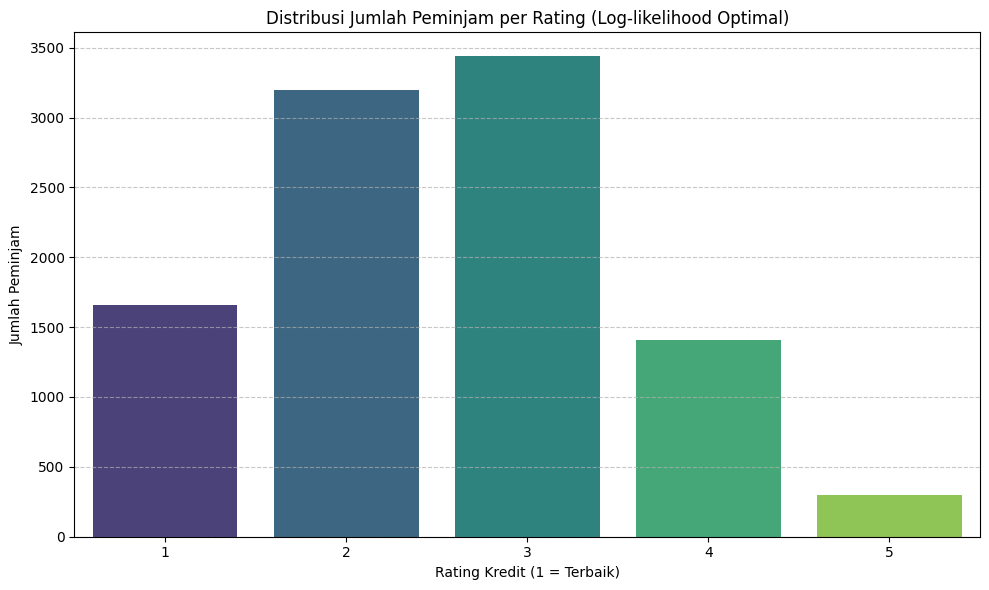

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming table_ll is available from the previous execution
# If running this cell independently, ensure table_ll is defined
# (e.g., by running the main execution block above or loading it)

fig = plt.figure(figsize=(10, 6))
sns.barplot(x='rating', y='n_borrowers', data=table_ll, palette='viridis')
plt.title('Distribusi Jumlah Peminjam per Rating (Log-likelihood Optimal)')
plt.xlabel('Rating Kredit (1 = Terbaik)')
plt.ylabel('Jumlah Peminjam')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Jumlah Peminjam per Rating (Log-likelihood-optimal)

In [19]:
display(table_ll[['rating', 'n_borrowers']])

,rating,n_borrowers
0,1,1657
1,2,3197
2,3,3438
3,4,1407
4,5,301


### Tingkat Gagal Bayar (PD) per Rating (Log-likelihood Optimal)

/tmp/ipykernel_1309/2781967510.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y=table_ll['default_rate_pd'] * 100, data=table_ll, palette='viridis')


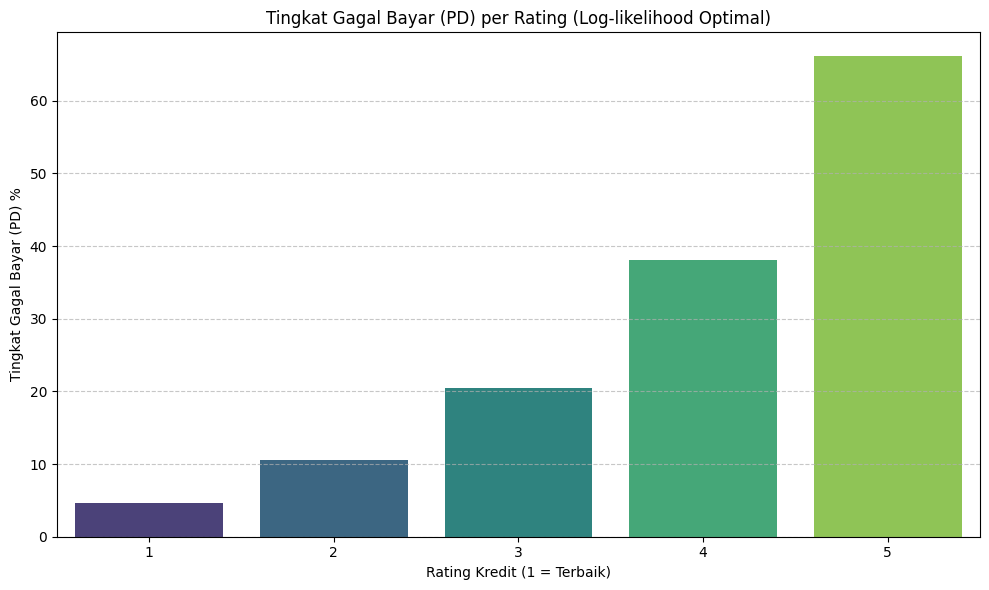

In [20]:
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='rating', y=table_ll['default_rate_pd'] * 100, data=table_ll, palette='viridis')
plt.title('Tingkat Gagal Bayar (PD) per Rating (Log-likelihood Optimal)')
plt.xlabel('Rating Kredit (1 = Terbaik)')
plt.ylabel('Tingkat Gagal Bayar (PD) %')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Tingkat Gagal Bayar (PD) per Rating (Log-likelihood Optimal)

In [21]:
display(table_ll[['rating', 'default_rate_pd']].style.format({'default_rate_pd': '{:.2%}'}))

,rating,default_rate_pd
0,1,4.65%
1,2,10.51%
2,3,20.45%
3,4,38.10%
4,5,66.11%
